In [450]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [451]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')

In [452]:
train.shape , test.shape

((8693, 14), (4277, 13))

In [453]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,False
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,True
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,False
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,False
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,True


In [454]:
test_passenger_ids = test['PassengerId']

In [455]:
with pd.ExcelWriter('spaceship_Titanic.xlsx') as writer:
    train.to_excel(writer,sheet_name='train')
    test.to_excel(writer,sheet_name='test')

### EDA :


In [456]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 8693 entries, 0 to 8692
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   8693 non-null   str    
 1   HomePlanet    8492 non-null   str    
 2   CryoSleep     8476 non-null   object 
 3   Cabin         8494 non-null   str    
 4   Destination   8511 non-null   str    
 5   Age           8514 non-null   float64
 6   VIP           8490 non-null   object 
 7   RoomService   8512 non-null   float64
 8   FoodCourt     8510 non-null   float64
 9   ShoppingMall  8485 non-null   float64
 10  Spa           8510 non-null   float64
 11  VRDeck        8505 non-null   float64
 12  Name          8493 non-null   str    
 13  Transported   8693 non-null   bool   
dtypes: bool(1), float64(6), object(2), str(5)
memory usage: 1.2+ MB


In [457]:
train.isnull().sum()

PassengerId       0
HomePlanet      201
CryoSleep       217
Cabin           199
Destination     182
Age             179
VIP             203
RoomService     181
FoodCourt       183
ShoppingMall    208
Spa             183
VRDeck          188
Name            200
Transported       0
dtype: int64

In [458]:
train.duplicated().sum()

np.int64(0)

In [459]:
train.describe()

,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck
count,8514.000000,8512.000000,8510.000000,8485.000000,8510.000000,8505.000000
mean,28.827930,224.687617,458.077203,173.729169,311.138778,304.854791
std,14.489021,666.717663,1611.489240,604.696458,1136.705535,1145.717189
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,19.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,38.000000,47.000000,76.000000,27.000000,59.000000,46.000000
max,79.000000,14327.000000,29813.000000,23492.000000,22408.000000,24133.000000


In [460]:
import sheryanalysis as sh  
sh.analyze(train)


🔍 Basic Analysis Report
------------------------------------------------------------
📏 Shape: (8693, 14)
🧱 Columns: ['PassengerId', 'HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name', 'Transported']

🧼 Columns with nulls: ['HomePlanet', 'CryoSleep', 'Cabin', 'Destination', 'Age', 'VIP', 'RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Name']

🔠 Categorical Columns: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'Transported']

🔢 Numerical Columns: ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

📝 Text Columns: ['PassengerId', 'Cabin', 'Name']


{'shape': (8693, 14),
 'columns': ['PassengerId',
  'HomePlanet',
  'CryoSleep',
  'Cabin',
  'Destination',
  'Age',
  'VIP',
  'RoomService',
  'FoodCourt',
  'ShoppingMall',
  'Spa',
  'VRDeck',
  'Name',
  'Transported'],
 'dtypes': {'PassengerId': <StringDtype(na_value=nan)>,
  'HomePlanet': <StringDtype(na_value=nan)>,
  'CryoSleep': dtype('O'),
  'Cabin': <StringDtype(na_value=nan)>,
  'Destination': <StringDtype(na_value=nan)>,
  'Age': dtype('float64'),
  'VIP': dtype('O'),
  'RoomService': dtype('float64'),
  'FoodCourt': dtype('float64'),
  'ShoppingMall': dtype('float64'),
  'Spa': dtype('float64'),
  'VRDeck': dtype('float64'),
  'Name': <StringDtype(na_value=nan)>,
  'Transported': dtype('bool')},
 'null_counts': {'PassengerId': 0,
  'HomePlanet': 201,
  'CryoSleep': 217,
  'Cabin': 199,
  'Destination': 182,
  'Age': 179,
  'VIP': 203,
  'RoomService': 181,
  'FoodCourt': 183,
  'ShoppingMall': 208,
  'Spa': 183,
  'VRDeck': 188,
  'Name': 200,
  'Transported': 0},
 'tot

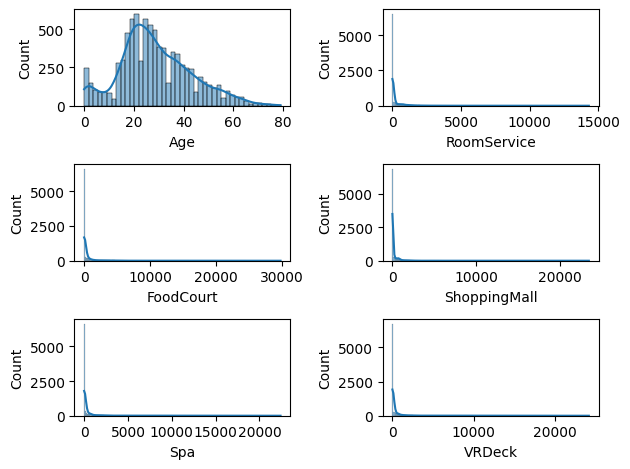

In [461]:
## Numerical Columns

def plotting(var,num):
    plt.subplot(3,2,num)
    sns.histplot(train[var],kde = True)
    # sns.boxplot(train[var])

plotting('Age',1)
plotting('RoomService',2)
plotting('FoodCourt',3)
plotting('ShoppingMall',4)
plotting('Spa',5)
plotting('VRDeck',6)




plt.tight_layout()

<Axes: xlabel='Age', ylabel='Count'>

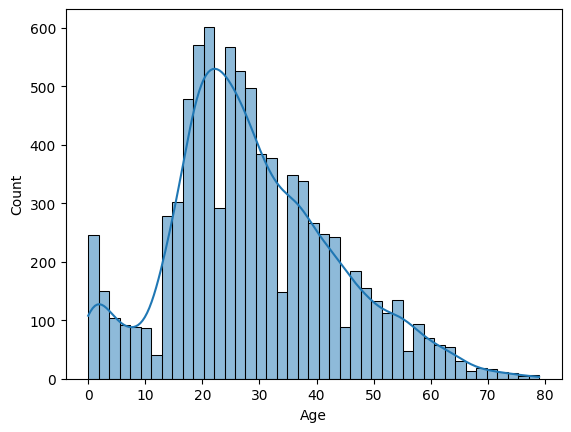

In [462]:
sns.histplot(train['Age'],kde=True)

In [463]:
train[(train['Age'] > 60)]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Transported
28,0024_01,Europa,True,C/2/S,TRAPPIST-1e,62.0,False,0.0,0.0,NaN,0.0,0.0,Penton Fullided,True
57,0062_01,Earth,False,F/13/S,TRAPPIST-1e,62.0,False,0.0,592.0,0.0,17.0,25.0,Sterry Greeves,False
60,0066_01,Earth,False,G/6/P,TRAPPIST-1e,62.0,False,1.0,153.0,197.0,0.0,460.0,Diandy Pecketton,False
109,0113_01,Earth,False,F/23/P,TRAPPIST-1e,64.0,False,0.0,0.0,804.0,0.0,0.0,Idary Carvis,True
118,0126_01,Mars,True,F/27/S,TRAPPIST-1e,67.0,False,0.0,0.0,0.0,0.0,0.0,Milly Mish,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8369,8954_01,Earth,False,G/1452/P,PSO J318.5-22,73.0,False,1806.0,0.0,47.0,0.0,0.0,Ianne Torrez,False
8516,9085_01,Europa,False,A/95/P,55 Cancri e,70.0,False,0.0,2113.0,0.0,1972.0,51.0,NaN,False
8539,9118_02,Earth,False,G/1482/P,TRAPPIST-1e,64.0,False,37.0,1585.0,234.0,0.0,18.0,Gwendy Malliamsey,True
8662,9242_01,Earth,False,F/1891/P,TRAPPIST-1e,62.0,False,102.0,696.0,0.0,0.0,0.0,Dary Bakerrison,True


In [464]:
print(train['Age'].isnull().sum()/len(train['Age']))

0.020591280340503854


In [465]:
# Categorical Columns: ['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'VIP', 'Transported']

# 1. Transported

train['Transported'].value_counts()

Transported
True     4378
False    4315
Name: count, dtype: int64

In [466]:
# 2. Cryosleep

train['CryoSleep'].isnull().sum()

np.int64(217)

<Axes: xlabel='CryoSleep', ylabel='count'>

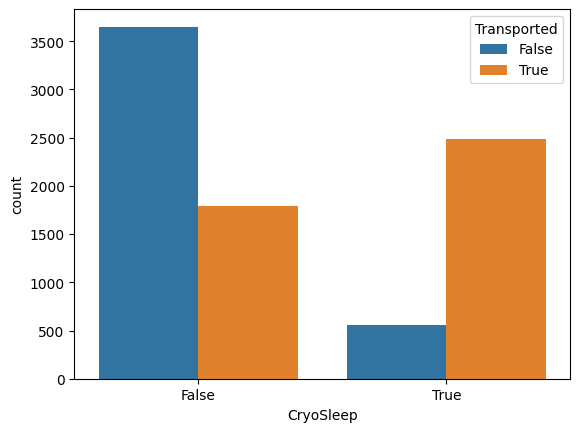

In [467]:
sns.countplot(data=train,x='CryoSleep', hue='Transported')

In [468]:
pd.crosstab(train['Transported'],train['CryoSleep'],normalize='columns')*100

CryoSleep,False,True
Transported,,
False,67.107924,18.241686
True,32.892076,81.758314


In [469]:
# 2. HomePlanet

train['HomePlanet'].isnull().sum()

np.int64(201)

<Axes: >

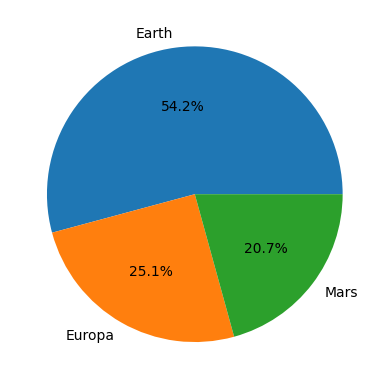

In [470]:
train['HomePlanet'].value_counts().plot(kind='pie',autopct='%0.1f%%')



<Axes: xlabel='HomePlanet', ylabel='count'>

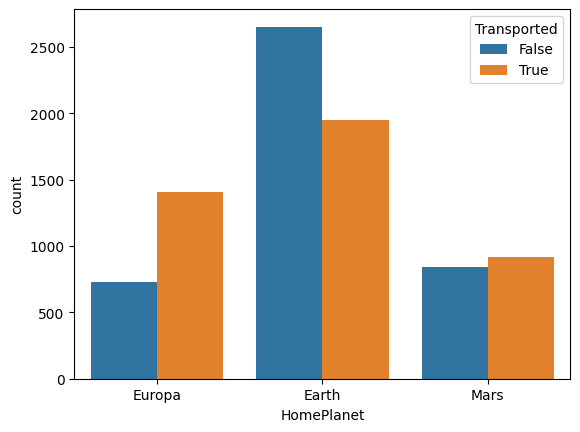

In [471]:
sns.countplot(data=train,x='HomePlanet',hue='Transported')

In [472]:
pd.crosstab(train['Transported'],train['HomePlanet'],normalize='columns')*100

HomePlanet,Earth,Europa,Mars
Transported,,,
False,57.605389,34.115439,47.697555
True,42.394611,65.884561,52.302445


<Axes: >

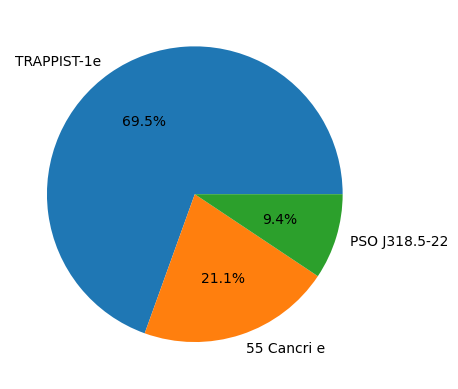

In [473]:
# 3. Destination

train['Destination'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='Destination', ylabel='count'>

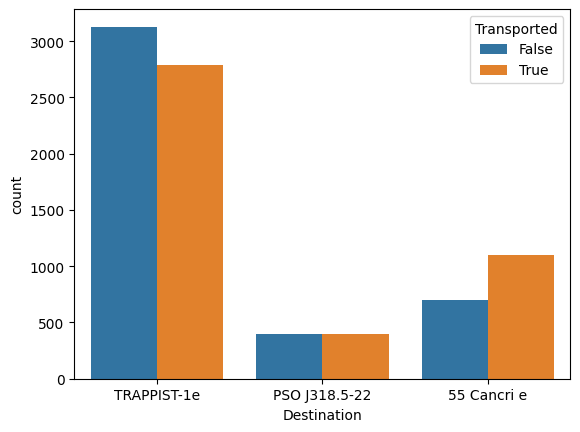

In [474]:
sns.countplot(data=train,x='Destination',hue='Transported')

In [475]:
pd.crosstab(train['Transported'],train['Destination'],normalize='columns')*100

Destination,55 Cancri e,PSO J318.5-22,TRAPPIST-1e
Transported,,,
False,39.0,49.623116,52.882502
True,61.0,50.376884,47.117498


<Axes: >

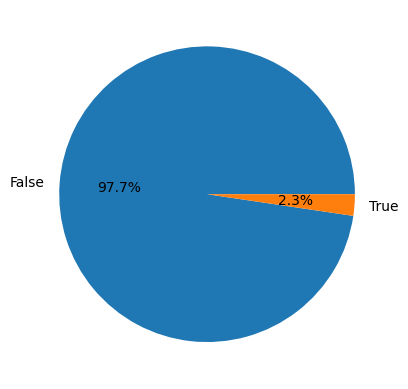

In [476]:
# 4. VIP

train['VIP'].value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: xlabel='VIP', ylabel='count'>

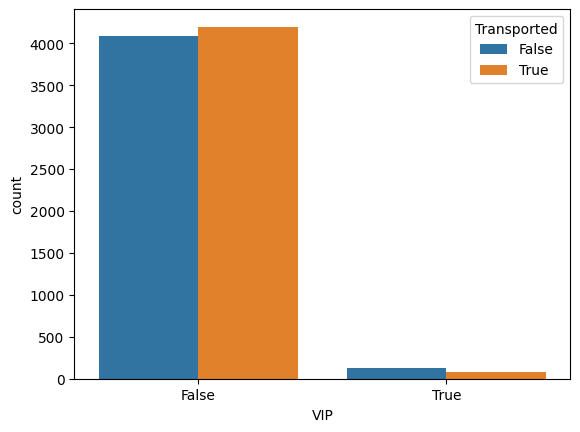

In [477]:
sns.countplot(data=train,x='VIP',hue='Transported')

<Axes: xlabel='Deck', ylabel='count'>

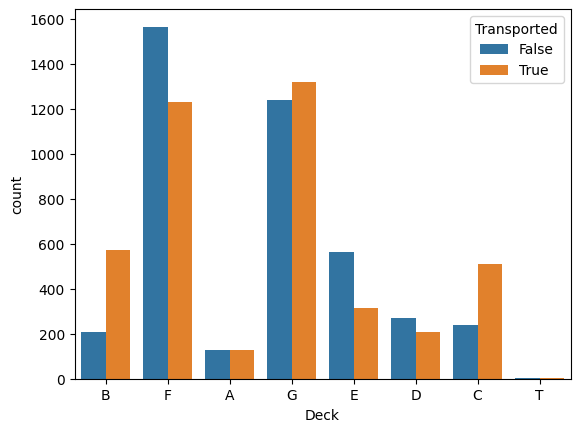

In [478]:
# 5. Deck extract from cabin

train[['Deck','CabinNumber','Side']] = train['Cabin'].str.split("/",expand=True)

sns.countplot(data=train,x='Deck',hue='Transported')

In [479]:
test[['Deck','CabinNumber','Side']] = test['Cabin'].str.split("/",expand=True)

In [480]:
pd.crosstab(train['Transported'],train['Deck'],normalize='columns')*100

Deck,A,B,C,D,E,F,G,T
Transported,,,,,,,,
False,50.390625,26.572529,31.994645,56.694561,64.269406,56.012885,48.378273,80.0
True,49.609375,73.427471,68.005355,43.305439,35.730594,43.987115,51.621727,20.0


In [481]:
pd.crosstab(train['Transported'],train['Side'],normalize='columns')*100

Side,P,S
Transported,,
False,54.87399,44.496269
True,45.12601,55.503731


<Axes: xlabel='Age', ylabel='Density'>

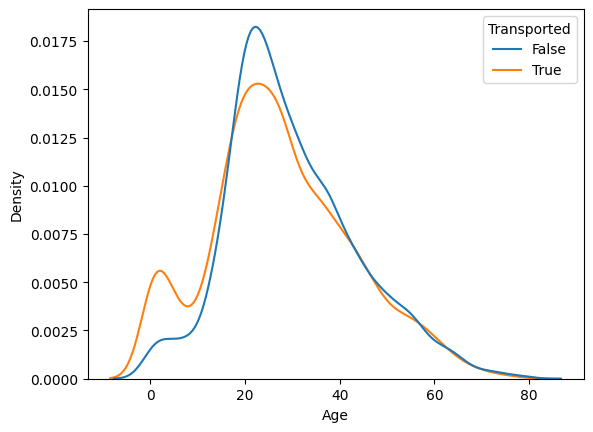

In [482]:
# Age vs transported

sns.kdeplot(data= train,x='Age',hue='Transported')

<Axes: xlabel='Age'>

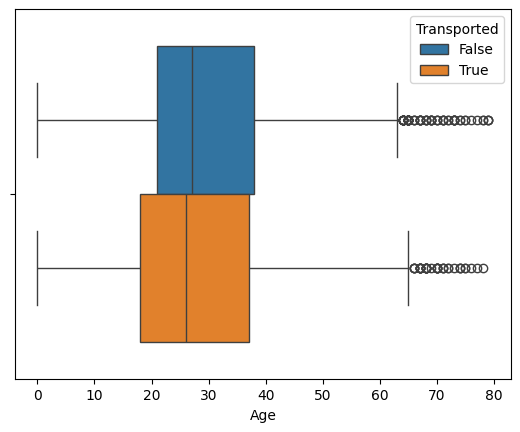

In [483]:
sns.boxplot(data=train,x='Age',hue='Transported')

<Axes: xlabel='Age'>

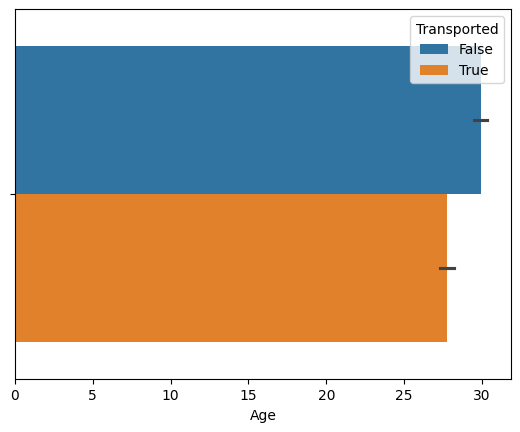

In [484]:
sns.barplot(data=train,x='Age',hue='Transported')

In [485]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

train['TotalSpend'] = train[spend_cols].sum(axis=1)
test['TotalSpend'] = test[spend_cols].sum(axis=1)

In [486]:
train['NoSpend'] = (train['TotalSpend'] == 0).astype(int)
test['NoSpend'] = (test['TotalSpend'] == 0).astype(int)



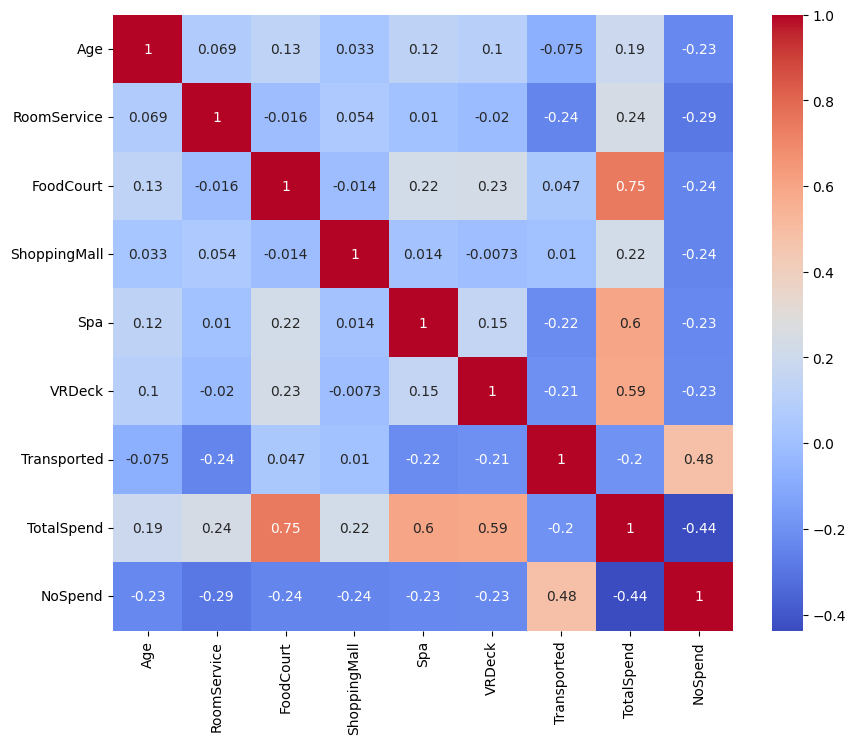

In [487]:
temp = train.copy()
temp["Transported"] = temp["Transported"].astype(int)

numeric = temp.select_dtypes(include=["number"])

corr = numeric.corr()

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

## Conclusion :

- Transported good relation with numeric columns (RoomService,spa,VRDeck,TotalSpend,NoSpend)
- Transported good relation with cat columns (CryoSleep, Destination, some Deck (A,B,C,E),Home Planet, Side)

### Cleaning Data and Features Engineering 

In [488]:
# separate the target element

y = train['Transported']

train = train.drop('Transported',axis=1)

In [489]:
train.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNumber,Side,TotalSpend,NoSpend
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39.0,False,0.0,0.0,0.0,0.0,0.0,Maham Ofracculy,B,0,P,0.0,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24.0,False,109.0,9.0,25.0,549.0,44.0,Juanna Vines,F,0,S,736.0,0
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58.0,True,43.0,3576.0,0.0,6715.0,49.0,Altark Susent,A,0,S,10383.0,0
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33.0,False,0.0,1283.0,371.0,3329.0,193.0,Solam Susent,A,0,S,5176.0,0
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16.0,False,303.0,70.0,151.0,565.0,2.0,Willy Santantines,F,1,S,1091.0,0


In [490]:
test.head()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNumber,Side,TotalSpend,NoSpend
0,0013_01,Earth,True,G/3/S,TRAPPIST-1e,27.0,False,0.0,0.0,0.0,0.0,0.0,Nelly Carsoning,G,3,S,0.0,1
1,0018_01,Earth,False,F/4/S,TRAPPIST-1e,19.0,False,0.0,9.0,0.0,2823.0,0.0,Lerome Peckers,F,4,S,2832.0,0
2,0019_01,Europa,True,C/0/S,55 Cancri e,31.0,False,0.0,0.0,0.0,0.0,0.0,Sabih Unhearfus,C,0,S,0.0,1
3,0021_01,Europa,False,C/1/S,TRAPPIST-1e,38.0,False,0.0,6652.0,0.0,181.0,585.0,Meratz Caltilter,C,1,S,7418.0,0
4,0023_01,Earth,False,F/5/S,TRAPPIST-1e,20.0,False,10.0,0.0,635.0,0.0,0.0,Brence Harperez,F,5,S,645.0,0


In [491]:
combined_df = pd.concat([train, test], ignore_index=True)

In [492]:
combined_df.tail()

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNumber,Side,TotalSpend,NoSpend
12965,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34.0,False,0.0,0.0,0.0,0.0,0.0,Jeron Peter,G,1496,S,0.0,1
12966,9269_01,Earth,False,NaN,TRAPPIST-1e,42.0,False,0.0,847.0,17.0,10.0,144.0,Matty Scheron,NaN,NaN,NaN,1018.0,0
12967,9271_01,Mars,True,D/296/P,55 Cancri e,NaN,False,0.0,0.0,0.0,0.0,0.0,Jayrin Pore,D,296,P,0.0,1
12968,9273_01,Europa,False,D/297/P,NaN,NaN,False,0.0,2680.0,0.0,0.0,523.0,Kitakan Conale,D,297,P,3203.0,0
12969,9277_01,Earth,True,G/1498/S,PSO J318.5-22,43.0,False,0.0,0.0,0.0,0.0,0.0,Lilace Leonzaley,G,1498,S,0.0,1


In [493]:
spend_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
combined_df[spend_cols] = combined_df[spend_cols].fillna(0)

In [494]:
combined_df['CryoSleep']=combined_df['CryoSleep'].fillna(combined_df['NoSpend'] == 1)

In [495]:
combined_df['CabinNumber']=combined_df['CabinNumber'].astype('Int64')
combined_df['Age']=combined_df['Age'].astype('Int64')
combined_df['RoomService']=combined_df['RoomService'].astype(int)
combined_df['FoodCourt']=combined_df['FoodCourt'].astype(int)
combined_df['ShoppingMall']=combined_df['ShoppingMall'].astype(int)
combined_df['Spa']=combined_df['Spa'].astype(int)
combined_df['VRDeck']=combined_df['VRDeck'].astype(int)

In [496]:
# Fill Cabin features

combined_df['Deck'] = combined_df['Deck'].fillna('Unknown')

combined_df['Side'] = combined_df['Side'].fillna('Unknown')

combined_df['CabinNumber'] = combined_df['CabinNumber'].fillna(
    combined_df['CabinNumber'].median()
)

In [497]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  str    
 1   HomePlanet    12682 non-null  str    
 2   CryoSleep     12970 non-null  object 
 3   Cabin         12671 non-null  str    
 4   Destination   12696 non-null  str    
 5   Age           12700 non-null  Int64  
 6   VIP           12674 non-null  object 
 7   RoomService   12970 non-null  int64  
 8   FoodCourt     12970 non-null  int64  
 9   ShoppingMall  12970 non-null  int64  
 10  Spa           12970 non-null  int64  
 11  VRDeck        12970 non-null  int64  
 12  Name          12676 non-null  str    
 13  Deck          12970 non-null  str    
 14  CabinNumber   12970 non-null  Int64  
 15  Side          12970 non-null  str    
 16  TotalSpend    12970 non-null  float64
 17  NoSpend       12970 non-null  int64  
dtypes: Int64(2), float64(1), int64(6), ob

In [498]:
# Fill Age 

combined_df['Age'] = combined_df.groupby('HomePlanet')['Age'].transform(
    lambda x: x.fillna(x.median())
)

combined_df['Age'] = combined_df['Age'].fillna(combined_df['Age'].median())

In [499]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  str    
 1   HomePlanet    12682 non-null  str    
 2   CryoSleep     12970 non-null  object 
 3   Cabin         12671 non-null  str    
 4   Destination   12696 non-null  str    
 5   Age           12970 non-null  Int64  
 6   VIP           12674 non-null  object 
 7   RoomService   12970 non-null  int64  
 8   FoodCourt     12970 non-null  int64  
 9   ShoppingMall  12970 non-null  int64  
 10  Spa           12970 non-null  int64  
 11  VRDeck        12970 non-null  int64  
 12  Name          12676 non-null  str    
 13  Deck          12970 non-null  str    
 14  CabinNumber   12970 non-null  Int64  
 15  Side          12970 non-null  str    
 16  TotalSpend    12970 non-null  float64
 17  NoSpend       12970 non-null  int64  
dtypes: Int64(2), float64(1), int64(6), ob

In [500]:
# Fill VIP

combined_df['VIP'] = combined_df['VIP'].fillna(False)

In [501]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  str    
 1   HomePlanet    12682 non-null  str    
 2   CryoSleep     12970 non-null  object 
 3   Cabin         12671 non-null  str    
 4   Destination   12696 non-null  str    
 5   Age           12970 non-null  Int64  
 6   VIP           12970 non-null  object 
 7   RoomService   12970 non-null  int64  
 8   FoodCourt     12970 non-null  int64  
 9   ShoppingMall  12970 non-null  int64  
 10  Spa           12970 non-null  int64  
 11  VRDeck        12970 non-null  int64  
 12  Name          12676 non-null  str    
 13  Deck          12970 non-null  str    
 14  CabinNumber   12970 non-null  Int64  
 15  Side          12970 non-null  str    
 16  TotalSpend    12970 non-null  float64
 17  NoSpend       12970 non-null  int64  
dtypes: Int64(2), float64(1), int64(6), ob

In [502]:
# Split PassendgerId

combined_df['GroupID'] = combined_df['PassengerId'].str.split("_").str.get(0)



In [503]:
combined_df['GroupSize'] = combined_df.groupby('GroupID')['GroupID'].transform('count')

In [504]:
combined_df

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Name,Deck,CabinNumber,Side,TotalSpend,NoSpend,GroupID,GroupSize
0,0001_01,Europa,False,B/0/P,TRAPPIST-1e,39,False,0,0,0,0,0,Maham Ofracculy,B,0,P,0.0,1,0001,1
1,0002_01,Earth,False,F/0/S,TRAPPIST-1e,24,False,109,9,25,549,44,Juanna Vines,F,0,S,736.0,0,0002,1
2,0003_01,Europa,False,A/0/S,TRAPPIST-1e,58,True,43,3576,0,6715,49,Altark Susent,A,0,S,10383.0,0,0003,2
3,0003_02,Europa,False,A/0/S,TRAPPIST-1e,33,False,0,1283,371,3329,193,Solam Susent,A,0,S,5176.0,0,0003,2
4,0004_01,Earth,False,F/1/S,TRAPPIST-1e,16,False,303,70,151,565,2,Willy Santantines,F,1,S,1091.0,0,0004,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12965,9266_02,Earth,True,G/1496/S,TRAPPIST-1e,34,False,0,0,0,0,0,Jeron Peter,G,1496,S,0.0,1,9266,2
12966,9269_01,Earth,False,NaN,TRAPPIST-1e,42,False,0,847,17,10,144,Matty Scheron,Unknown,431,Unknown,1018.0,0,9269,1
12967,9271_01,Mars,True,D/296/P,55 Cancri e,28,False,0,0,0,0,0,Jayrin Pore,D,296,P,0.0,1,9271,1
12968,9273_01,Europa,False,D/297/P,NaN,33,False,0,2680,0,0,523,Kitakan Conale,D,297,P,3203.0,0,9273,1


In [505]:
combined_df['IsAlone'] = (combined_df['GroupSize'] == 1).astype(int)

In [506]:
combined_df[combined_df['HomePlanet'].isnull()]

,PassengerId,HomePlanet,CryoSleep,Cabin,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,...,VRDeck,Name,Deck,CabinNumber,Side,TotalSpend,NoSpend,GroupID,GroupSize,IsAlone
59,0064_02,NaN,True,E/3/S,TRAPPIST-1e,27,False,0,0,0,...,0,Colatz Keen,E,3,S,0.0,1,0064,2,0
113,0119_01,NaN,False,A/0/P,TRAPPIST-1e,27,False,0,2344,0,...,6898,Batan Coning,A,0,P,9307.0,0,0119,2,0
186,0210_01,NaN,True,D/6/P,55 Cancri e,27,False,0,0,0,...,0,Arraid Inicont,D,6,P,0.0,1,0210,1,1
225,0242_01,NaN,False,F/46/S,TRAPPIST-1e,27,False,313,1,691,...,0,Almone Sté,F,46,S,1288.0,0,0242,1,1
234,0251_01,NaN,True,C/11/S,55 Cancri e,27,False,0,0,0,...,0,Diphah Amsive,C,11,S,0.0,1,0251,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12650,8621_01,NaN,False,E/552/P,TRAPPIST-1e,27,False,4,0,1604,...,0,Vanley Simmonders,E,552,P,1608.0,0,8621,1,1
12673,8678_01,NaN,True,G/1399/S,55 Cancri e,27,False,0,0,0,...,0,Eilan Kellson,G,1399,S,0.0,1,8678,2,0
12725,8775_01,NaN,True,D/275/P,TRAPPIST-1e,27,False,0,0,0,...,0,Raston Maltorted,D,275,P,0.0,1,8775,1,1
12852,9025_01,NaN,False,G/1454/S,TRAPPIST-1e,27,False,0,0,28,...,0,Ale Whitersone,G,1454,S,754.0,0,9025,2,0


In [507]:
# fill the HomePlanet

def fill_homeplanet(group):
    mode = group.mode()

    if len(mode) > 0:
        return group.fillna(mode.iloc[0])

    return group


combined_df["HomePlanet"] = (
    combined_df.groupby("GroupID")["HomePlanet"].transform(fill_homeplanet)
)



In [508]:
combined_df['HomePlanet'].isnull().sum()

np.int64(157)

In [509]:
combined_df["HomePlanet"] = combined_df["HomePlanet"].fillna(
    combined_df["HomePlanet"].mode()[0]
)

In [510]:
# fill destination

def fill_destination(group):
    mode = group.mode()

    if len(mode) > 0:
        return group.fillna(mode.iloc[0])

    return group


combined_df["Destination"] = (
    combined_df.groupby("GroupID")["Destination"].transform(fill_homeplanet)
)

combined_df["Destination"] = combined_df["Destination"].fillna(
    combined_df["Destination"].mode()[0]
)

In [511]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  str    
 1   HomePlanet    12970 non-null  str    
 2   CryoSleep     12970 non-null  object 
 3   Cabin         12671 non-null  str    
 4   Destination   12970 non-null  str    
 5   Age           12970 non-null  Int64  
 6   VIP           12970 non-null  object 
 7   RoomService   12970 non-null  int64  
 8   FoodCourt     12970 non-null  int64  
 9   ShoppingMall  12970 non-null  int64  
 10  Spa           12970 non-null  int64  
 11  VRDeck        12970 non-null  int64  
 12  Name          12676 non-null  str    
 13  Deck          12970 non-null  str    
 14  CabinNumber   12970 non-null  Int64  
 15  Side          12970 non-null  str    
 16  TotalSpend    12970 non-null  float64
 17  NoSpend       12970 non-null  int64  
 18  GroupID       12970 non-null  object 

In [512]:
# SPLIT the name into surname

combined_df["Surname"] = combined_df["Name"].str.split().str[-1]

In [513]:
combined_df["Surname"] = combined_df["Surname"].fillna("Unknown")

In [514]:
combined_df.drop(["Name","Cabin"], axis=1, inplace=True)

In [515]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 20 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   PassengerId   12970 non-null  str    
 1   HomePlanet    12970 non-null  str    
 2   CryoSleep     12970 non-null  object 
 3   Destination   12970 non-null  str    
 4   Age           12970 non-null  Int64  
 5   VIP           12970 non-null  object 
 6   RoomService   12970 non-null  int64  
 7   FoodCourt     12970 non-null  int64  
 8   ShoppingMall  12970 non-null  int64  
 9   Spa           12970 non-null  int64  
 10  VRDeck        12970 non-null  int64  
 11  Deck          12970 non-null  str    
 12  CabinNumber   12970 non-null  Int64  
 13  Side          12970 non-null  str    
 14  TotalSpend    12970 non-null  float64
 15  NoSpend       12970 non-null  int64  
 16  GroupID       12970 non-null  object 
 17  GroupSize     12970 non-null  int64  
 18  IsAlone       12970 non-null  int64  

## Age Group:

- 0-12 : child

- 13-18 : teen

- 19-35  : Young adult

- 36-60 : adult

- 60+ : Senior

In [516]:
combined_df["AgeGroup"] = pd.cut(
    combined_df["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"],
    include_lowest=True
)

In [517]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 21 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   PassengerId   12970 non-null  str     
 1   HomePlanet    12970 non-null  str     
 2   CryoSleep     12970 non-null  object  
 3   Destination   12970 non-null  str     
 4   Age           12970 non-null  Int64   
 5   VIP           12970 non-null  object  
 6   RoomService   12970 non-null  int64   
 7   FoodCourt     12970 non-null  int64   
 8   ShoppingMall  12970 non-null  int64   
 9   Spa           12970 non-null  int64   
 10  VRDeck        12970 non-null  int64   
 11  Deck          12970 non-null  str     
 12  CabinNumber   12970 non-null  Int64   
 13  Side          12970 non-null  str     
 14  TotalSpend    12970 non-null  float64 
 15  NoSpend       12970 non-null  int64   
 16  GroupID       12970 non-null  object  
 17  GroupSize     12970 non-null  int64   
 18  IsAlone       129

## Further Features Engineering 

In [600]:
combined_df["LuxurySpend"] = combined_df["Spa"] + combined_df["VRDeck"]

combined_df["BasicSpend"] = (
    combined_df["RoomService"]
    + combined_df["FoodCourt"]
    + combined_df["ShoppingMall"]
)

combined_df["NoSpend"] = (combined_df["TotalSpend"] == 0).astype(int)

combined_df["LuxuryRatio"] = combined_df["LuxurySpend"]/(combined_df["TotalSpend"]+1)

combined_df["FoodRatio"] = combined_df["FoodCourt"]/(combined_df["TotalSpend"]+1)

combined_df["FamilySpend"] = combined_df["TotalSpend"]/combined_df["GroupSize"]

combined_df["AgeSpend"] = combined_df["Age"]*combined_df["TotalSpend"]

In [ ]:
combined_df["Cryo_NoSpend"] = (
    combined_df["CryoSleep"].astype(int) * combined_df["NoSpend"]
)



In [660]:
drop_cols = [
    "Cryo_TotalSpend",
    "Cryo_Luxury"
]

combined_df = combined_df.drop(columns=drop_cols)

In [628]:
combined_df["CabinRegion"] = pd.cut(
    combined_df["CabinNumber"],
    bins=[0,300,600,900,1200,2000],
    labels=["Front","FrontMid","Middle","RearMid","Rear"],
    include_lowest=True
)

In [521]:
combined_df['Surname'].value_counts()

Surname
Unknown       294
Buckentry      19
Belley         19
Hinglendez     18
Casonston      18
             ... 
Cherticale      1
Moncy           1
Dranionfic      1
Reetholt        1
Bare            1
Name: count, Length: 2407, dtype: int64

In [522]:
combined_df['Surname'] = combined_df['Surname'].astype(str)
combined_df['CryoSleep'] = combined_df['CryoSleep'].astype(int)
combined_df['VIP'] = combined_df['VIP'].astype(int)

In [523]:
combined_df['Age'] = combined_df['Age'].astype(int)
combined_df['CabinNumber'] = combined_df['CabinNumber'].astype(int)
combined_df['TotalSpend'] = combined_df['TotalSpend'].astype(int)

In [607]:
combined_df["CryoSleep"] = combined_df["CryoSleep"].astype(bool)
combined_df["VIP"] = combined_df["VIP"].astype(bool)

In [629]:
cat_cols = [
    "HomePlanet",
    "Destination",
    "Deck",
    "Side",
    "Surname",
    "AgeGroup",
    "CabinRegion"
]

for col in cat_cols:
    combined_df[col] = combined_df[col].astype("category")

In [609]:
combined_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 12970 entries, 0 to 12969
Data columns (total 26 columns):
 #   Column        Non-Null Count  Dtype   
---  ------        --------------  -----   
 0   HomePlanet    12970 non-null  category
 1   CryoSleep     12970 non-null  bool    
 2   Destination   12970 non-null  category
 3   Age           12970 non-null  int64   
 4   VIP           12970 non-null  bool    
 5   RoomService   12970 non-null  int64   
 6   FoodCourt     12970 non-null  int64   
 7   ShoppingMall  12970 non-null  int64   
 8   Spa           12970 non-null  int64   
 9   VRDeck        12970 non-null  int64   
 10  Deck          12970 non-null  category
 11  CabinNumber   12970 non-null  int64   
 12  Side          12970 non-null  category
 13  TotalSpend    12970 non-null  int64   
 14  NoSpend       12970 non-null  int64   
 15  GroupSize     12970 non-null  int64   
 16  IsAlone       12970 non-null  int64   
 17  Surname       12970 non-null  category
 18  AgeGroup      129

In [525]:
pd.crosstab(combined_df["CryoSleep"], combined_df["NoSpend"])

NoSpend,0,1
CryoSleep,,
0,7513,740
1,0,4717


### Split the dataset into train and test

In [667]:
X_train_df = combined_df.iloc[:len(y)].copy()
X_test_df = combined_df.iloc[len(y):].copy()

In [680]:
X_train_df.head()

,HomePlanet,CryoSleep,Destination,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,...,Surname,AgeGroup,LuxurySpend,BasicSpend,LuxuryRatio,FoodRatio,FamilySpend,AgeSpend,CabinRegion,Cryo_NoSpend
0,Europa,False,TRAPPIST-1e,39,0,0,0,0,0,B,...,Ofracculy,Adult,0,0,0.000000,0.000000,0.0,0,Front,0
1,Earth,False,TRAPPIST-1e,24,109,9,25,549,44,F,...,Vines,YoungAdult,593,143,0.804613,0.012212,736.0,17664,Front,0
2,Europa,False,TRAPPIST-1e,58,43,3576,0,6715,49,A,...,Susent,Adult,6764,3619,0.651387,0.344376,5191.5,602214,Front,0
3,Europa,False,TRAPPIST-1e,33,0,1283,371,3329,193,A,...,Susent,YoungAdult,3522,1654,0.680317,0.247827,2588.0,170808,Front,0
4,Earth,False,TRAPPIST-1e,16,303,70,151,565,2,F,...,Santantines,Teen,567,524,0.519231,0.064103,1091.0,17456,Front,0


In [681]:
cleaned_train = X_train_df.copy()
cleaned_train["Transported"] = y

In [682]:
cleaned_train.to_csv("cleaned_train.csv", index=False)
X_test_df.to_csv("cleaned_test.csv", index=False)

In [668]:
X_train_df1 = X_train_df.drop('Surname',axis=1)
X_test_df1 = X_test_df.drop('Surname',axis=1)

#### ONE HOT Encoding

In [669]:
X_train_encoded = pd.get_dummies(X_train_df1).astype(int)
X_test_encoded = pd.get_dummies(X_test_df1).astype(int)

In [670]:
X_train_encoded

,CryoSleep,Age,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,CabinNumber,TotalSpend,LuxurySpend,...,AgeGroup_Child,AgeGroup_Teen,AgeGroup_YoungAdult,AgeGroup_Adult,AgeGroup_Senior,CabinRegion_Front,CabinRegion_FrontMid,CabinRegion_Middle,CabinRegion_RearMid,CabinRegion_Rear
0,0,39,0,0,0,0,0,0,0,0,...,0,0,0,1,0,1,0,0,0,0
1,0,24,109,9,25,549,44,0,736,593,...,0,0,1,0,0,1,0,0,0,0
2,0,58,43,3576,0,6715,49,0,10383,6764,...,0,0,0,1,0,1,0,0,0,0
3,0,33,0,1283,371,3329,193,0,5176,3522,...,0,0,1,0,0,1,0,0,0,0
4,0,16,303,70,151,565,2,1,1091,567,...,0,1,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8688,0,41,0,6819,0,1643,74,98,8536,1717,...,0,0,0,1,0,1,0,0,0,0
8689,1,18,0,0,0,0,0,1499,0,0,...,0,1,0,0,0,0,0,0,0,1
8690,0,26,0,0,1872,1,0,1500,1873,1,...,0,0,1,0,0,0,0,0,0,1
8691,0,32,0,1049,0,353,3235,608,4637,3588,...,0,0,1,0,0,0,0,1,0,0


In [568]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_train_df,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [547]:
X_train_df.head()

,HomePlanet,CryoSleep,Destination,Age,VIP,RoomService,FoodCourt,ShoppingMall,Spa,VRDeck,Deck,CabinNumber,Side,TotalSpend,NoSpend,GroupSize,IsAlone,Surname,AgeGroup
0,Europa,0,TRAPPIST-1e,39,0,0,0,0,0,0,B,0,P,0,1,1,1,Ofracculy,Adult
1,Earth,0,TRAPPIST-1e,24,0,109,9,25,549,44,F,0,S,736,0,1,1,Vines,YoungAdult
2,Europa,0,TRAPPIST-1e,58,1,43,3576,0,6715,49,A,0,S,10383,0,2,0,Susent,Adult
3,Europa,0,TRAPPIST-1e,33,0,0,1283,371,3329,193,A,0,S,5176,0,2,0,Susent,YoungAdult
4,Earth,0,TRAPPIST-1e,16,0,303,70,151,565,2,F,1,S,1091,0,1,1,Santantines,Teen


In [665]:
X_train_df.columns

Index(['HomePlanet', 'CryoSleep', 'Destination', 'Age', 'RoomService',
       'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck', 'Deck', 'CabinNumber',
       'Side', 'TotalSpend', 'Surname', 'AgeGroup', 'LuxurySpend',
       'BasicSpend', 'LuxuryRatio', 'FoodRatio', 'FamilySpend', 'AgeSpend',
       'CabinRegion', 'Cryo_NoSpend'],
      dtype='str')

In [672]:
cat_features = [
    "HomePlanet",
    "CryoSleep",
    "Destination",
    "Deck",
    "Side",
    "Surname",
    "AgeGroup",
    "CabinRegion"
]

In [648]:
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

In [649]:
params = {
    "iterations": 5000,
    "learning_rate": 0.02,
    "depth": 6,
    "l2_leaf_reg": 7,
    "random_strength": 2,
    "bagging_temperature": 1,
    "loss_function": "Logloss",
    "eval_metric": "Accuracy",
    "random_seed": 42,
    "od_type": "Iter",
    "od_wait": 300,
    "verbose": 200
}

In [650]:
from catboost import CatBoostClassifier

pred_test = np.zeros(len(X_test_df))

for train_idx,val_idx in skf.split(X_train_df,y):

    Xtr = X_train_df.iloc[train_idx]
    Xval = X_train_df.iloc[val_idx]

    ytr = y.iloc[train_idx]
    yval = y.iloc[val_idx]

    model = CatBoostClassifier(**params)

    model.fit(
    Xtr,
    ytr,
    eval_set=(Xval, yval),
    cat_features=cat_features,
    use_best_model=True,
    early_stopping_rounds=300
    )

    pred_test += model.predict_proba(X_test_df)[:,1]/5

0:	learn: 0.7686224	test: 0.7814836	best: 0.7814836 (0)	total: 231ms	remaining: 19m 15s
200:	learn: 0.8045729	test: 0.8096607	best: 0.8102358 (170)	total: 31.8s	remaining: 12m 40s
400:	learn: 0.8175151	test: 0.8136860	best: 0.8154112 (314)	total: 49s	remaining: 9m 22s
600:	learn: 0.8330457	test: 0.8131110	best: 0.8154112 (314)	total: 1m 5s	remaining: 8m 2s
Stopped by overfitting detector  (300 iterations wait)

bestTest = 0.8154111558
bestIteration = 314

Shrink model to first 315 iterations.
0:	learn: 0.7714984	test: 0.7688327	best: 0.7688327 (0)	total: 85ms	remaining: 7m 4s
200:	learn: 0.8096060	test: 0.7918344	best: 0.7924094 (173)	total: 16.5s	remaining: 6m 32s
400:	learn: 0.8180903	test: 0.8021852	best: 0.8021852 (385)	total: 28s	remaining: 5m 21s
600:	learn: 0.8331895	test: 0.7993099	best: 0.8027602 (403)	total: 40.9s	remaining: 4m 59s
800:	learn: 0.8431119	test: 0.8056354	best: 0.8062105 (693)	total: 52.7s	remaining: 4m 36s
Stopped by overfitting detector  (300 iterations wait)


In [ ]:
submission = pd.DataFrame({
    "PassengerId":test["PassengerId"],
    "Transported":pred_test>0.5
})

submission.to_csv(
    "sample_submission9.csv",
    index=False
)

In [641]:
importance = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Importance": model.get_feature_importance()
}).sort_values("Importance", ascending=False)

print(importance)

         Feature  Importance
21   LuxuryRatio   12.653618
0     HomePlanet    9.623379
10          Deck    9.097271
5    RoomService    8.721201
19   LuxurySpend    6.627814
23   FamilySpend    6.133166
12          Side    5.964395
25   CabinRegion    5.391839
22     FoodRatio    5.048445
13    TotalSpend    4.286016
2    Destination    3.644657
1      CryoSleep    3.636966
7   ShoppingMall    3.355558
18      AgeGroup    2.701157
24      AgeSpend    2.318034
11   CabinNumber    2.116005
8            Spa    1.640045
3            Age    1.389996
6      FoodCourt    1.196593
9         VRDeck    1.123798
20    BasicSpend    1.108948
17       Surname    0.931957
14       NoSpend    0.747106
15     GroupSize    0.440180
4            VIP    0.058494
16       IsAlone    0.043362


### CatBoost Classifier

In [673]:
from catboost import CatBoostClassifier

cat_model = CatBoostClassifier(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    random_seed=42,
    
    verbose=False
)

cat_model.fit(
    X_train_df,
    y,
    cat_features=cat_features
)

CatBoostClassifier(depth=6, iterations=500, learning_rate=0.05, random_seed=42, verbose=False)

In [658]:
cat_predictions = cat_model.predict(X_test_df)

cat_predictions = cat_predictions.astype(bool)

submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": cat_predictions
})
submission.to_csv("sample_submission10.csv", index=False)

In [674]:
importance = cat_model.get_feature_importance()

feature_importance = pd.DataFrame({
    "Feature": X_train_df.columns,
    "Importance": importance
}).sort_values("Importance", ascending=False)

print(feature_importance)

         Feature  Importance
17   LuxuryRatio   10.622013
9           Deck    9.632798
0     HomePlanet    8.508427
4    RoomService    7.355693
15   LuxurySpend    7.090534
11          Side    5.847194
12    TotalSpend    5.525367
10   CabinNumber    5.137476
21   CabinRegion    4.778717
18     FoodRatio    4.747192
6   ShoppingMall    3.868999
14      AgeGroup    3.483058
22  Cryo_NoSpend    3.345613
2    Destination    3.182142
3            Age    3.090441
20      AgeSpend    2.018036
5      FoodCourt    1.989027
19   FamilySpend    1.897304
16    BasicSpend    1.884086
13       Surname    1.765612
8         VRDeck    1.475390
1      CryoSleep    1.403046
7            Spa    1.351834


In [576]:
test['PassengerId']

0       0013_01
1       0018_01
2       0019_01
3       0021_01
4       0023_01
         ...   
4272    9266_02
4273    9269_01
4274    9271_01
4275    9273_01
4276    9277_01
Name: PassengerId, Length: 4277, dtype: str

In [ ]:
submission.to_csv("sample_submission10.csv", index=False)

In [583]:
submission.head()

,PassengerId,Transported
0,0013_01,True
1,0018_01,False
2,0019_01,True
3,0021_01,True
4,0023_01,True


In [675]:
from sklearn.preprocessing import LabelEncoder

X_train_xgb = X_train_df.copy()
X_test_xgb = X_test_df.copy()

encoders = {}

for col in X_train_xgb.select_dtypes(include=['object', 'category']).columns:
    le = LabelEncoder()

    combined = pd.concat([
        X_train_xgb[col],
        X_test_xgb[col]
    ]).astype(str)

    le.fit(combined)

    X_train_xgb[col] = le.transform(X_train_xgb[col].astype(str))
    X_test_xgb[col] = le.transform(X_test_xgb[col].astype(str))

    encoders[col] = le

In [676]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)

xgb_model.fit(X_train_xgb, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,0.8
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method

In [678]:
cat_prob = cat_model.predict_proba(X_test_df)[:,1]                                             
xgb_prob = xgb_model.predict_proba(X_test_xgb)[:,1]                                                    

final_prob = (0.70 * cat_prob + 0.30 * xgb_prob)    
final_prediction = final_prob > 0.5  

In [679]:
submission = pd.DataFrame({
    "PassengerId": test["PassengerId"],
    "Transported": final_prediction
})

submission.to_csv("sample_submission11.csv", index=False)

### Prediction Accuracy:

- `CatBoost` : 81.7%
- `XGBoost` : 82.01 %
- `RandomBoost` : 80.8%
- `GradientBoost` : 80.50%
- `SVM` : 79.7% & fi-score (81.1%) 

In [571]:
from sklearn.metrics import accuracy_score

# CatBoost
cat_pred = cat_model.predict(X_test)
print("CatBoost:", accuracy_score(y_test, cat_pred))

CatBoost: 0.8171362852213916


### XGBoost and Random Forest

In [585]:
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train_encoded, y)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,True
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_metho

In [587]:
# XGBoost
xgb_predictions = xgb_model.predict(X_test_encoded)
xgb_predictions = xgb_predictions.astype(bool)
submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": xgb_predictions
})
submission.to_csv("sample_submission2.csv", index=False)

In [586]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

rf_model.fit(X_train_encoded, y)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",300
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [588]:
# Random Forest
rf_predictions = rf_model.predict(X_test_encoded)
rf_predictions = rf_predictions.astype(bool)
submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": rf_predictions
})
submission.to_csv("sample_submission3.csv", index=False)



In [ ]:
from sklearn.metrics import accuracy_score

# CatBoost
cat_pred = cat_model.predict(X_test)
print("CatBoost:", accuracy_score(y_test, cat_pred))

# XGBoost
xgb_pred = xgb_model.predict(X_test)
print("XGBoost:", accuracy_score(y_test, xgb_pred))

# Random Forest
rf_pred = rf_model.predict(X_test)
print("Random Forest:", accuracy_score(y_test, rf_pred))

XGBoost: 0.8205865439907993
Random Forest: 0.8085106382978723


In [552]:

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, f1_score, classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import StackingClassifier, AdaBoostClassifier, GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder

In [537]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Stacking Classifier

In [593]:
base_learners1 = [
    ('dt',DecisionTreeClassifier(random_state=42)),
    ('svc',SVC(probability=True, kernel='rbf', random_state=42)),
    ('lr',LogisticRegression(max_iter=1000))
]

base_learners2 = [
    ('rf',RandomForestClassifier()),
    ('xgb',XGBClassifier()),
    ('gra',GradientBoostingClassifier())
]



meta_learner1 = LogisticRegression(max_iter=1000)
meta_learner2 = GradientBoostingClassifier()


In [594]:
stacking_clf = StackingClassifier(
    estimators=base_learners2,
    final_estimator=meta_learner2,
    cv = 5
)

In [595]:
stacking_clf.fit(X_train_encoded,y)

,"estimators estimators: list of (str, estimator)Base estimators which will be stacked together. Each element of thelist is defined as a tuple of string (i.e. name) and an estimatorinstance. An estimator can be set to 'drop' using `set_params`.The type of estimator is generally expected to be a classifier.However, one can pass a regressor for some use case (e.g. ordinalregression).","[('rf', ...), ('xgb', ...), ...]"
,"final_estimator final_estimator: estimator, default=NoneA classifier which will be used to combine the base estimators.The default classifier is a:class:`~sklearn.linear_model.LogisticRegression`.",GradientBoostingClassifier()
,"cv cv: int, cross-validation generator, iterable, or ""prefit"", default=NoneDetermines the cross-validation splitting strategy used in`cross_val_predict` to train `final_estimator`. Possible inputs forcv are:* None, to use the default 5-fold cross validation,* integer, to specify the number of folds in a (Stratified) KFold,* An object to be used as a cross-validation generator,* An iterable yielding train, test splits,* `""prefit""`, to assume the `estimators` are prefit. In this case, the estimators will not be refitted.For integer/None inputs, if the estimator is a classifier and y iseither binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used.In all other cases, :class:`~sklearn.model_selection.KFold` is used.These splitters are instantiated with `shuffle=False` so the splitswill be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here.If ""prefit"" is passed, it is assumed that all `estimators` havebeen fitted already. The `final_estimator_` is trained on the `estimators`predictions on the full training set and are **not** cross validatedpredictions. Please note that if the models have been trained on the samedata to train the stacking model, there is a very high risk of overfitting... versionadded:: 1.1 The 'prefit' option was added in 1.1.. note:: A larger number of split will provide no benefits if the number of training samples is large enough. Indeed, the training time will increase. ``cv`` is not used for model evaluation but for prediction.",5
,"stack_method stack_method: {'auto', 'predict_proba', 'decision_function', 'predict'}, default='auto'Methods called for each base estimator. It can be:* if 'auto', it will try to invoke, for each estimator, `'predict_proba'`, `'decision_function'` or `'predict'` in that order.* otherwise, one of `'predict_proba'`, `'decision_function'` or `'predict'`. If the method is not implemented by the estimator, it will raise an error.",'auto'
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for `fit` of all `estimators`.`None` means 1 unless in a `joblib.parallel_backend` context. -1 meansusing all processors. See :term:`Glossary ` for more details.",None
,"passthrough passthrough: bool, default=FalseWhen False, only the predictions of estimators will be used astraining data for `final_estimator`. When True, the`final_estimator` is trained on the predictions as well as theoriginal training data.",False
,"verbose verbose: int, default=0Verbosity level.",0
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of sa

In [596]:
# Stacking Classfier
st_predictions = stacking_clf.predict(X_test_encoded)
st_predictions = st_predictions.astype(bool)
submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": st_predictions
})
submission.to_csv("sample_submission6.csv", index=False)

In [567]:
y_pred = stacking_clf.predict(X_test)

acc = accuracy_score(y_pred,y_test)

print(acc)

0.8067855089131685


### AdaBoost Classifier

In [597]:
ada_model = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

In [598]:
ada_model.fit(X_train_encoded,y)

,"estimator estimator: object, default=NoneThe base estimator from which the boosted ensemble is built.Support for sample weighting is required, as well as proper``classes_`` and ``n_classes_`` attributes. If ``None``, thenthe base estimator is :class:`~sklearn.tree.DecisionTreeClassifier`initialized with `max_depth=1`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=50The maximum number of estimators at which boosting is terminated.In case of perfect fit, the learning procedure is stopped early.Values must be in the range `[1, inf)`.",100
,"learning_rate learning_rate: float, default=1.0Weight applied to each classifier at each boosting iteration. A higherlearning rate increases the contribution of each classifier. There isa trade-off between the `learning_rate` and `n_estimators` parameters.Values must be in the range `(0.0, inf)`.",1.0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given at each `estimator` at eachboosting iteration.Thus, it is only used when `estimator` exposes a `random_state`.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [599]:
# ADABoost
ada_predictions = ada_model.predict(X_test_encoded)
ada_predictions = ada_predictions.astype(bool)
submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": ada_predictions
})
submission.to_csv("sample_submission7.csv", index=False)

### Gradient Boost Classifier

In [589]:

gra_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    random_state=42
)

gra_model.fit(X_train_encoded,y)

,"loss loss: {'log_loss', 'exponential'}, default='log_loss'The loss function to be optimized. 'log_loss' refers to binomial andmultinomial deviance, the same as used in logistic regression.It is a good choice for classification with probabilistic outputs.For loss 'exponential', gradient boosting recovers the AdaBoost algorithm.",'log_loss'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.For an example of the effects of this parameter and its interaction with``subsample``, see:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_regularization.py`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are'friedman_mse' for the mean squared error with improvement score byFriedman, 'squared_error' for mean squared error. The default value of'friedman_mse' is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, 

In [ ]:
# Grad_Boost
gra_predictions = gra_model.predict(X_test_encoded)
gra_predictions = gra_predictions.astype(bool)
submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": gra_predictions
})
submission.to_csv("sample_submission4.csv", index=False)

In [563]:
y_pred = gra_model.predict(X_test)

acc = accuracy_score(y_pred,y_test)

print(acc)

0.8050603795284647


In [538]:
models = {
    "Logistic Regression": LogisticRegression(),
    "KNN": KNeighborsClassifier(),
    "Naive Bayes": GaussianNB(),
    "Decision Tree": DecisionTreeClassifier(),
    "SVM (RBF Kernel)": SVC(probability=True)
}

In [539]:
results = []

In [542]:
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    results.append({
        'Model': name,
        'Accuracy': round(acc, 4),
        'F1 Score': round(f1, 4)
    })

In [543]:
results

[{'Model': 'Logistic Regression', 'Accuracy': 0.789, 'F1 Score': 0.7923},
 {'Model': 'KNN', 'Accuracy': 0.7803, 'F1 Score': 0.7776},
 {'Model': 'Naive Bayes', 'Accuracy': 0.7677, 'F1 Score': 0.7918},
 {'Model': 'Decision Tree', 'Accuracy': 0.7476, 'F1 Score': 0.749},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.789, 'F1 Score': 0.785},
 {'Model': 'Logistic Regression', 'Accuracy': 0.7895, 'F1 Score': 0.7939},
 {'Model': 'KNN', 'Accuracy': 0.7723, 'F1 Score': 0.7793},
 {'Model': 'Naive Bayes', 'Accuracy': 0.778, 'F1 Score': 0.7979},
 {'Model': 'Decision Tree', 'Accuracy': 0.7464, 'F1 Score': 0.7504},
 {'Model': 'SVM (RBF Kernel)', 'Accuracy': 0.797, 'F1 Score': 0.8119}]

In [591]:
svm_model = SVC(kernel='rbf',probability=True,C=1)

svm_model.fit(X_train_encoded,y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",True
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [592]:
# SVM Model
svm_predictions = svm_model.predict(X_test_encoded)
svm_predictions = svm_predictions.astype(bool)
submission = pd.DataFrame({
    "PassengerId": test['PassengerId'],
    "Transported": svm_predictions
})
submission.to_csv("sample_submission5.csv", index=False)